In [1]:
%matplotlib inline
import matplotlib
import numpy as np
from scipy.stats import binned_statistic
import matplotlib.pyplot as plt

In [10]:
def com_distance_to_pmf(file, bins):
    ''' Load COM distance as a function of MC steps and calculate potential of mean forece (PMF) '''
    p, r = np.histogram(np.loadtxt(file), bins=bins)
    r = r[1:] / 2 + r[0:-1] / 2
    dr = r[1] - r[0]
    r_max = r[-1]
    gofr = p / p.sum() * r_max / dr # g(r)
    pmf = -np.log(gofr)             # w(r)/kT
    print(f"r_min = {r[0]}, r_max = {r_max} Å, dr = {dr} Å")
    return r, pmf

def getForces(xfile, yfile, bins):
    ''' get average force as a function of z-position of molecule B '''
    R = np.loadtxt(xfile, usecols=[0])
    steps, dL, du, force = np.loadtxt(yfile, unpack=True, skiprows=1)
    print(du)
    means, edges, bins = binned_statistic(R, np.exp(-du), statistic=np.nanmean, bins)
    print(f"r_min = {edges[0]}, r_max = {edges[-1]} Å, dr = {edges[1]-edges[0]} Å")
    return edges[1:], (np.log(means) / dL[0])

SyntaxError: positional argument follows keyword argument (1836185229.py, line 17)

r_min = 74.64176, r_max = 80.33624 Å, dr = 0.057519999999982474 Å
[          nan           nan           nan ... -5.636071e-06 -5.653768e-06
 -8.399458e-06]
r_min = 74.613, r_max = 80.365 Å, dr = 0.057519999999996685 Å
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan]


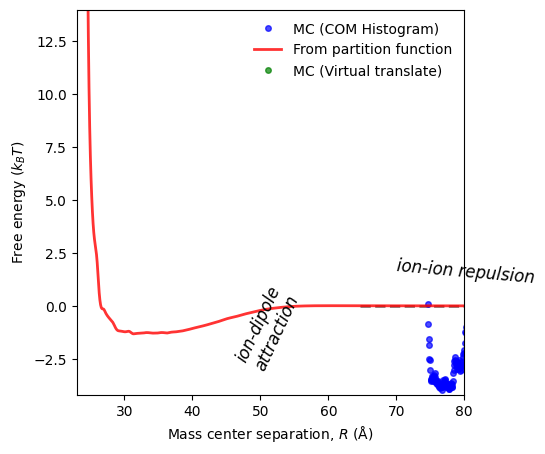

In [9]:
fig, ax = plt.subplots(nrows=1, figsize=(5, 5))
r, pmf = com_distance_to_pmf("com_distance_290.0.dat.gz", bins=100)
ax.hlines(0, xmin=r[0]-10, xmax=r[-1]+10, color='k', alpha=0.5, ls='--', lw=2)
ax.plot(r, pmf - 0.7, 'bo', lw=3, label="MC (COM Histogram)", alpha=0.7, ms=4)

r, pmf = np.loadtxt("scan_T293.dat", usecols=[0,1], unpack=True)
ax.plot(r, pmf, label="From partition function", lw=2, alpha=0.8, color='red')

R, force = getForces('com_distance_290.0.dat.gz', 'vt.dat_290.0.gz', 100)
pmf_vt = -np.cumsum(force)*np.diff(R)[:-2].mean() # integrate simulated force to get PMF
mean_tail_vt = np.mean(pmf_vt[-20:-1])
pmf_vt = pmf_vt - mean_tail_vt # Normalize
print(pmf_vt)
ax.plot(R, pmf_vt, 'go', lw=3, label="MC (Virtual translate)", alpha=0.7, ms=4)

ax.set_ylabel("Free energy ($k_BT$)")
ax.set_xlabel("Mass center separation, $R$ (Å)")
ax.legend(loc=0, frameon=False)
ax.set_xlim(23, 80)
ax.set_ylim(-4.2, 14)
ax.text(70, 1.1, "ion-ion repulsion", rotation=-5, fontstyle='italic', fontsize='large')
ax.text(46, -3, "ion-dipole\nattraction", rotation=65, fontstyle='italic', fontsize='large')
plt.savefig("twobody.png", bbox_inches="tight", dpi=300)
plt.show()